# 🧠 Task 5: Mental Health Support Chatbot

## Dataset
**Amod/mental_health_counseling_conversations** — real counselor-client pairs
- `Context` = user message
- `Response` = counselor reply

## Architecture
```
User Input -> Safety Pre-filter -> DistilGPT-2 (fine-tuned) -> Disclaimer -> Gradio UI
```
> **Before running:** Runtime -> Change runtime type -> T4 GPU
---

## Step 1: GPU Check

In [1]:
import torch
print(f'Device: {"GPU -- " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU -- switch to T4 GPU!"}')
if torch.cuda.is_available():
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: GPU -- Tesla T4
VRAM  : 15.6 GB


---
## Step 2: Install

In [2]:
!pip install transformers datasets accelerate gradio --quiet
print('Done!')

Done!


---
## Step 3: Imports

In [3]:
import os, re, math, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer,
    DataCollatorForLanguageModeling, set_seed
)
from torch.utils.data import Dataset
import gradio as gr

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110
print('Imports done. Device:', DEVICE.upper())

Imports done. Device: CUDA


---
## Step 4: Configuration

In [4]:
CFG = {
    'model_name'        : 'distilgpt2',
    'max_length'        : 128,
    'train_samples'     : 6000,
    'val_samples'       : 800,
    'output_dir'        : './mental_health_bot',
    'num_epochs'        : 3,
    'batch_size'        : 8,
    'grad_accumulation' : 4,
    'learning_rate'     : 5e-5,
    'warmup_steps'      : 100,
    'weight_decay'      : 0.01,
    'gen_max_new_tokens': 80,
    'gen_temperature'   : 0.75,
    'gen_top_p'         : 0.9,
    'gen_top_k'         : 50,
    'gen_repetition_pen': 1.2,
}
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Config loaded.')

Config loaded.


---
## Step 5: Load Dataset (with real Context + Response columns)

In [5]:
print('Loading dataset...')
raw_dataset = load_dataset('Amod/mental_health_counseling_conversations')
print('Done!')
print(f'  Size    : {len(raw_dataset["train"]):,}')
print(f'  Columns : {raw_dataset["train"].column_names}')
print('\nSample:')
print(raw_dataset['train'][0])

Loading dataset...


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

Done!
  Size    : 3,512
  Columns : ['Context', 'Response']

Sample:
{'Context': "I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here.\n   I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it.\n   How can I change my feeling of being worthless to everyone?", 'Response': "If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief t

---
## Step 6: EDA

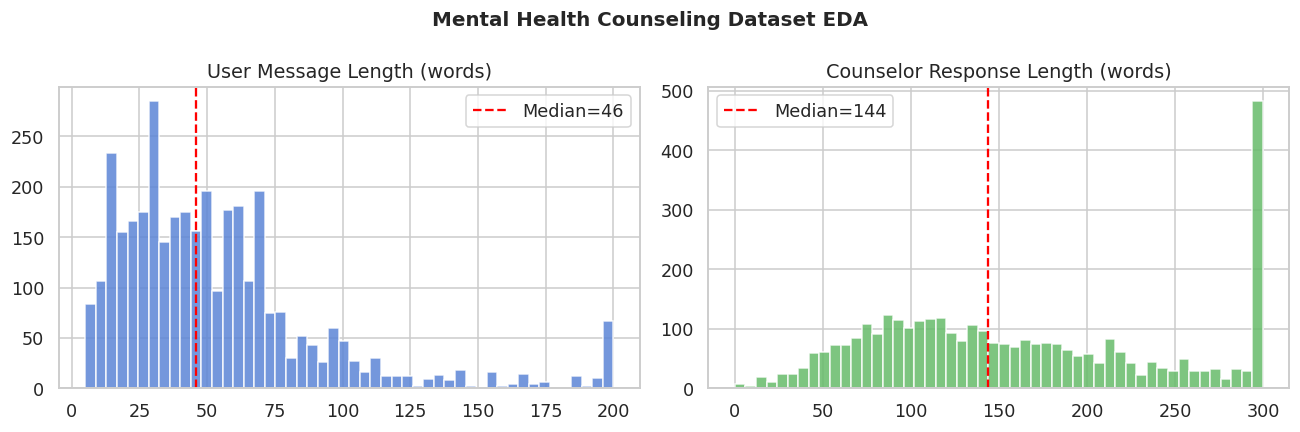

Total pairs: 3,512 | Avg ctx: 55w | Avg resp: 177w


In [6]:
df = raw_dataset['train'].to_pandas()
df['ctx_len']  = df['Context'].apply(lambda x: len(str(x).split()))
df['resp_len'] = df['Response'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['ctx_len'].clip(0,200),  bins=50, color='#5C85D6', edgecolor='white', alpha=0.85)
axes[0].axvline(df['ctx_len'].median(),  color='red', linestyle='--', linewidth=1.5, label=f'Median={df["ctx_len"].median():.0f}')
axes[0].set_title('User Message Length (words)')
axes[0].legend()
axes[1].hist(df['resp_len'].clip(0,300), bins=50, color='#66BB6A', edgecolor='white', alpha=0.85)
axes[1].axvline(df['resp_len'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Median={df["resp_len"].median():.0f}')
axes[1].set_title('Counselor Response Length (words)')
axes[1].legend()
plt.suptitle('Mental Health Counseling Dataset EDA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Total pairs: {len(df):,} | Avg ctx: {df["ctx_len"].mean():.0f}w | Avg resp: {df["resp_len"].mean():.0f}w')

---
## Step 7: Tokenizer & Special Tokens

In [7]:
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
tokenizer.pad_token = tokenizer.eos_token
tokenizer.add_special_tokens({'additional_special_tokens': ['<|prompt|>', '<|response|>']})
print(f'Tokenizer ready. Vocab: {len(tokenizer):,}')

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer ready. Vocab: 50,259


---
## Step 8: Data Formatting & Dataset

In [8]:
def format_sample(example):
    prompt   = ' '.join(str(example.get('Context',  '')).strip().split()[:60])
    response = ' '.join(str(example.get('Response', '')).strip().split()[:60])
    return f'<|prompt|> {prompt} <|response|> {response} {tokenizer.eos_token}'

print('Sample formatted:')
print(format_sample(raw_dataset['train'][0]))

Sample formatted:
<|prompt|> I'm going through some things with my feelings and myself. I barely sleep and I do nothing but think about how I'm worthless and how I shouldn't be here. I've never tried or contemplated suicide. I've always wanted to fix my issues, but I never get around to it. How can I change my feeling of being worthless to everyone? <|response|> If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages <|endoftext|>


In [9]:
class CounselingDataset(Dataset):
    def __init__(self, hf_data, tokenizer, max_length, n_samples=None):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        data = hf_data
        if n_samples:
            data = data.select(range(min(n_samples, len(data))))
        self.texts = [format_sample(ex) for ex in data]
        print(f'  Built: {len(self.texts):,} samples')

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_length,
                             truncation=True, padding='max_length', return_tensors='pt')
        ids   = enc['input_ids'].squeeze()
        mask  = enc['attention_mask'].squeeze()
        labels = ids.clone()
        labels[mask == 0] = -100
        return {'input_ids': ids, 'attention_mask': mask, 'labels': labels}

full   = raw_dataset['train'].shuffle(seed=42)
n_tr   = int(len(full) * 0.9)
print('Building datasets...')
train_dataset = CounselingDataset(full.select(range(n_tr)),         tokenizer, CFG['max_length'], CFG['train_samples'])
val_dataset   = CounselingDataset(full.select(range(n_tr,len(full))),tokenizer, CFG['max_length'], CFG['val_samples'])
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,}')

Building datasets...
  Built: 3,160 samples
  Built: 352 samples
Train: 3,160 | Val: 352


---
## Step 9: Load Model

In [10]:
model = AutoModelForCausalLM.from_pretrained(CFG['model_name'])
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.pad_token_id
model = model.to(DEVICE)
params = sum(p.numel() for p in model.parameters())
print(f'Model loaded! Params: {params/1e6:.1f}M | Device: {DEVICE}')

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model loaded! Params: 81.9M | Device: cuda


---
## Step 10: Generate Response Function

In [11]:
def generate_response(user_input: str) -> str:
    """Generate empathetic response from fine-tuned model."""
    model.eval()
    prompt = f'<|prompt|> {user_input} <|response|>'
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=CFG['max_length']).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens     = CFG['gen_max_new_tokens'],
            temperature        = CFG['gen_temperature'],
            top_p              = CFG['gen_top_p'],
            top_k              = CFG['gen_top_k'],
            repetition_penalty = CFG['gen_repetition_pen'],
            do_sample          = True,
            pad_token_id       = tokenizer.eos_token_id,
        )
    new_tokens = out[0][inputs['input_ids'].shape[1]:]
    resp = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    sents = re.split(r'(?<=[.!?])\s+', resp)
    return ' '.join(sents[:3]) if len(sents) > 3 else (resp or '[No response generated]')

print('generate_response() ready.')

generate_response() ready.


---
## Step 11: Baseline Test (Before Fine-Tuning)

In [12]:
TEST_QUERIES = [
    'I have been feeling really anxious about my exams.',
    'I feel so lonely and nobody understands me.',
    'I am overwhelmed with work and cannot cope anymore.',
    'I had a really bad day and everything went wrong.',
]

print('BASELINE (before fine-tuning):')
print('-' * 60)
for q in TEST_QUERIES:
    print(f'User: {q}')
    print(f'Bot : {generate_response(q)}')
    print()

BASELINE (before fine-tuning):
------------------------------------------------------------
User: I have been feeling really anxious about my exams.
Bot : , you know that it's a little difficult to get through the exam and then pass on all of those things when there are no deadlines (in this case in class). But now we've got time for testing out new features so far – here is what some people had said:
You can start by getting feedback from other students who were asking how they would handle your tests! This could be an

User: I feel so lonely and nobody understands me.
Bot : 's the one that is really trying to make people uncomfortable because of my sexual orientation, since it all depends on how much they like you or what type of person she looks for when in a relationship."
The answer was simple: You should be happy with your sexuality until someone else gets angry at them; if anyone does not want her (and who can blame him), then he shouldn't even bother

User: I am overwhelmed wit

---
## Step 12: Train

In [13]:
training_args = TrainingArguments(
    output_dir                  = CFG['output_dir'],
    num_train_epochs            = CFG['num_epochs'],
    per_device_train_batch_size = CFG['batch_size'],
    per_device_eval_batch_size  = CFG['batch_size'],
    gradient_accumulation_steps = CFG['grad_accumulation'],
    learning_rate               = CFG['learning_rate'],
    warmup_steps                = CFG['warmup_steps'],
    weight_decay                = CFG['weight_decay'],
    logging_steps               = 50,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    fp16                        = torch.cuda.is_available(),
    report_to                   = 'none',
    remove_unused_columns       = False,
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

print('Starting fine-tuning (~15-25 min on T4)...')
train_result = trainer.train()
print(f'Done! Loss: {train_result.metrics["train_loss"]:.4f} | Time: {train_result.metrics["train_runtime"]:.0f}s')

Starting fine-tuning (~15-25 min on T4)...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,3.601865,3.086356
2,3.091673,2.850880
3,2.885563,2.799397


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Done! Loss: 3.1242 | Time: 128s


In [14]:
model.save_pretrained(CFG['output_dir'])
tokenizer.save_pretrained(CFG['output_dir'])
print(f'Saved to {CFG["output_dir"]}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ./mental_health_bot


---
## Step 13: Loss & Perplexity Curves

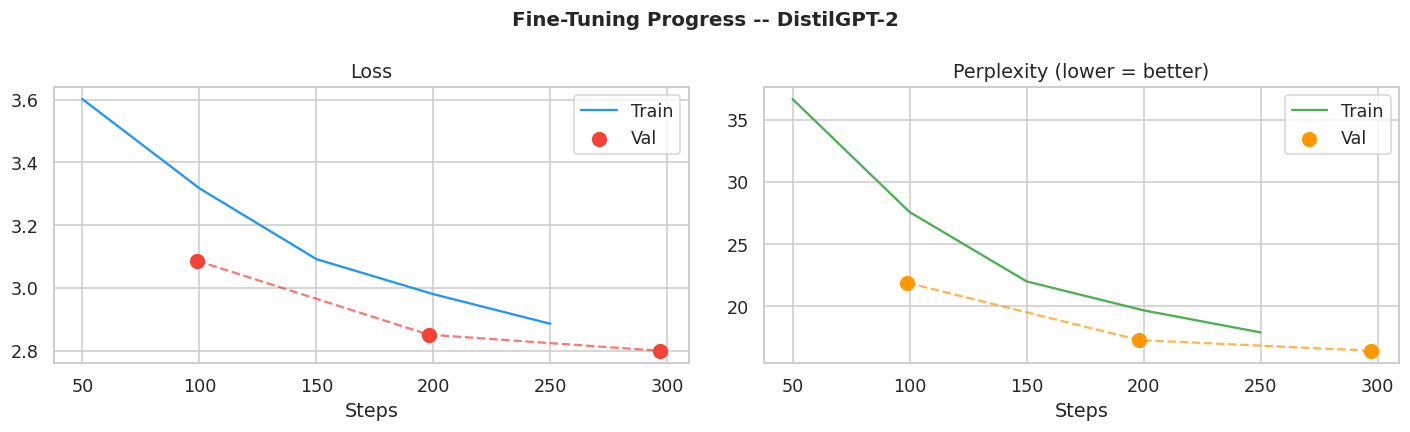

Final eval loss: 2.7994 | Perplexity: 16.43


In [15]:
logs        = trainer.state.log_history
tr_logs     = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
ev_logs     = [x for x in logs if 'eval_loss' in x]
tr_steps    = [x['step'] for x in tr_logs]
tr_loss     = [x['loss'] for x in tr_logs]
ev_steps    = [x['step'] for x in ev_logs]
ev_loss     = [x['eval_loss'] for x in ev_logs]
tr_ppl      = [math.exp(min(l,20)) for l in tr_loss]
ev_ppl      = [math.exp(min(l,20)) for l in ev_loss]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(tr_steps, tr_loss, '#2196F3', linewidth=1.5, label='Train')
axes[0].scatter(ev_steps, ev_loss, color='#F44336', s=80, zorder=5, label='Val')
axes[0].plot(ev_steps, ev_loss, '#F44336', linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].set_title('Loss')
axes[0].set_xlabel('Steps')
axes[0].legend()
axes[1].plot(tr_steps, tr_ppl, '#4CAF50', linewidth=1.5, label='Train')
axes[1].scatter(ev_steps, ev_ppl, color='#FF9800', s=80, zorder=5, label='Val')
axes[1].plot(ev_steps, ev_ppl, '#FF9800', linewidth=1.5, linestyle='--', alpha=0.7)
axes[1].set_title('Perplexity (lower = better)')
axes[1].set_xlabel('Steps')
axes[1].legend()
plt.suptitle('Fine-Tuning Progress -- DistilGPT-2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
if ev_loss:
    print(f'Final eval loss: {ev_loss[-1]:.4f} | Perplexity: {math.exp(min(ev_loss[-1],20)):.2f}')

---
## Step 14: Post Fine-Tuning Test

In [16]:
print('POST FINE-TUNING RESPONSES:')
print('-' * 60)
for q in TEST_QUERIES:
    print(f'User: {q}')
    print(f'Bot : {generate_response(q)}')
    print()

POST FINE-TUNING RESPONSES:
------------------------------------------------------------
User: I have been feeling really anxious about my exams.
Bot : It sounds like your anxiety is going away and you're not alone in wanting to be more confident because of what comes out during the tests or for them as well, that's actually true! You are also seeing a lot less negative results than if it was just an issue with having all those things come up when they were being presented (e-mailing me). If this doesn't sound right then

User: I feel so lonely and nobody understands me.
Bot : In a society, it sounds like you are just people who don't have much experience or expertise in life's things - but if they truly want to know more about what is happening with the world around them there would be some time before we reach adulthood where someone will find out whether he/she can help him through any of this stuff... It might even work for everyone! Also remember that your mother

User: I am overw

---
## Step 15: Safety Layer

In [17]:
CRISIS_PATTERNS = [
    r'suicid', r'kill\s*my\s*self', r'want\s+to\s+die',
    r'end\s+(my|this)\s+life', r'self[\s-]?harm',
    r'hurt\s+my\s*self', r'no\s+reason\s+to\s+live',
    r'better\s+off\s+dead', r'want\s+to\s+disappear',
]

ESCALATION_KEYWORDS = [
    'panic attack', "can't breathe", 'losing my mind',
    'complete breakdown', 'lost all hope', 'nothing matters',
]

CRISIS_RESPONSE = (
    'I hear you, and I am really glad you reached out.\n\n'
    'Please talk to someone who can truly help right now:\n\n'
    'Pakistan -- Umang helpline: 0317-4288665\n'
    'Pakistan -- Umang WhatsApp: 0311-7786264\n\n'
    'International -- Crisis Text Line: Text HOME to 741741\n\n'
    'You are not alone. Things can get better with the right support.'
)

DISCLAIMER = (
    '\n\n---\n'
    '_I am an AI assistant, not a therapist. '
    'If you are struggling, please consider speaking with a mental health professional._'
)

def safety_check(text: str) -> dict:
    t = text.lower()
    for p in CRISIS_PATTERNS:
        if re.search(p, t):
            return {'status': 'crisis'}
    for kw in ESCALATION_KEYWORDS:
        if kw in t:
            return {'status': 'escalation'}
    return {'status': 'safe'}

print('Safety layer ready.')
print(f'Crisis patterns  : {len(CRISIS_PATTERNS)}')
print(f'Escalation terms : {len(ESCALATION_KEYWORDS)}')
print(f'Crisis test      : {safety_check("I want to end my life")["status"]}')
print(f'Normal test      : {safety_check("I feel anxious today")["status"]}')

Safety layer ready.
Crisis patterns  : 9
Escalation terms : 6
Crisis test      : crisis
Normal test      : safe


---
## Step 16: Gradio Chatbot UI

> Full-featured chat interface with:
> - Crisis detection & helpline response
> - Escalation note for high-risk messages
> - AI disclaimer on every response
> - Sidebar with quick example buttons
> - Clear conversation button

In [18]:
def bot_response(user_message: str, chat_history: list) -> tuple:
    """
    Main chatbot function for Gradio.
    Pipeline:
      1. Safety check (crisis / escalation / safe)
      2. Generate response from fine-tuned model
      3. Append escalation note or disclaimer
      4. Update chat history
    Returns: (updated_history, empty_string_to_clear_input)
    """
    if not user_message.strip():
        return chat_history, ''

    check = safety_check(user_message)

    if check['status'] == 'crisis':
        response = CRISIS_RESPONSE

    else:
        response = generate_response(user_message)

        if check['status'] == 'escalation':
            response += (
                '\n\nIt sounds like you are going through something very hard. '
                'Please consider reaching out to a counselor or trusted person in your life.'
            )

        response += DISCLAIMER

    chat_history.append((user_message, response))
    return chat_history, ''


def clear_chat() -> tuple:
    """Reset the conversation."""
    return [], ''


EXAMPLE_MESSAGES = [
    'I have been feeling really anxious about my exams.',
    'I feel so lonely and nobody understands me.',
    'I am overwhelmed with work and cannot cope anymore.',
    'I had a really bad day and everything went wrong.',
    'I am scared about what the future holds for me.',
    'I have been struggling with sleep due to stress.',
]

# ── Build Gradio UI ──────────────────────────────────────────────────
with gr.Blocks(
    title       = 'MindfulBot',
    theme       = gr.themes.Soft(primary_hue='blue', secondary_hue='slate'),
    css         = """
        .disclaimer { font-size: 0.78rem; color: #666; margin-top: 4px; }
        footer { display: none !important; }
    """
) as demo:

    # ── Header ──────────────────────────────────────────────────────
    gr.Markdown("""
    # 🧠 MindfulBot -- Mental Health Support
    **Fine-tuned DistilGPT-2 on real counseling conversations**

    > ⚠️ **This is not a substitute for professional mental health care.**
    > For emergencies call **115** (Pakistan) or **112** (International).
    """)

    with gr.Row():

        # ── Left: Chat ──────────────────────────────────────────────
        with gr.Column(scale=3):
            chatbot = gr.Chatbot(
                label           = 'MindfulBot',
                height          = 460,
                bubble_full_width = False,
                show_label      = True,
                avatar_images   = (None, None),
                value           = [(
                    None,
                    'Hello! I am MindfulBot. I am here to listen and offer support. '
                    'How are you feeling today?'
                )],
            )

            with gr.Row():
                msg_box  = gr.Textbox(
                    placeholder = 'Share what is on your mind...',
                    label       = '',
                    lines       = 2,
                    scale       = 5,
                )
                send_btn = gr.Button('Send', variant='primary', scale=1)

            clear_btn = gr.Button('Clear Conversation', variant='secondary', size='sm')

        # ── Right: Sidebar ──────────────────────────────────────────
        with gr.Column(scale=1):
            gr.Markdown('### 💬 Quick Examples')
            gr.Markdown('*Click to fill the message box:*')

            for ex in EXAMPLE_MESSAGES:
                gr.Button(ex, size='sm').click(
                    fn      = lambda x=ex: x,
                    outputs = msg_box
                )

            gr.Markdown('---')
            gr.Markdown("""
            ### 🛡️ Safety
            - Crisis detection active
            - Helpline numbers ready
            - Disclaimer on every reply

            ### 📚 Model Info
            - **Base**: DistilGPT-2 (82M)
            - **Data**: Mental Health Counseling
            - **Epochs**: 3

            ### 🚨 Emergency
            **Pakistan**: 115 or 1122
            **International**: 112
            """)

    # ── Event bindings ───────────────────────────────────────────────
    send_btn.click(
        fn      = bot_response,
        inputs  = [msg_box, chatbot],
        outputs = [chatbot, msg_box],
    )
    msg_box.submit(
        fn      = bot_response,
        inputs  = [msg_box, chatbot],
        outputs = [chatbot, msg_box],
    )
    clear_btn.click(
        fn      = clear_chat,
        outputs = [chatbot, msg_box],
    )

demo.launch(share=True, debug=False)
print('MindfulBot Gradio app launched!')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://076d8d9393254a787a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


MindfulBot Gradio app launched!


---
## Step 17: Final Summary

| Component | Detail |
|---|---|
| Base model | DistilGPT-2 (82M params) |
| Dataset | Amod/mental_health_counseling_conversations |
| Format | `<\|prompt\|> user <\|response\|> counselor` |
| Epochs | 3 with early stopping |
| Safety | Crisis (9 patterns) + Escalation + Disclaimer |
| UI | Gradio Chatbot with sidebar + examples |

### Safety Layers

| Layer | Trigger | Action |
|---|---|---|
| Crisis pre-filter | 9 regex patterns | Bypass model, show helpline |
| Escalation filter | 6 keyword phrases | Model responds + support note |
| AI disclaimer | Always | Appended to every response |

In [19]:
print('=' * 55)
print('  MINDFULBOT -- SUMMARY')
print('=' * 55)
print(f'  Model          : DistilGPT-2 (82M params)')
print(f'  Dataset        : Amod/mental_health_counseling_conversations')
print(f'  Train samples  : {CFG["train_samples"]:,}')
print(f'  Epochs         : {CFG["num_epochs"]}')
print(f'  Batch (eff)    : {CFG["batch_size"] * CFG["grad_accumulation"]}')
print(f'  fp16           : {torch.cuda.is_available()}')
print(f'  UI             : Gradio (share=True)')
print(f'  Crisis patterns: {len(CRISIS_PATTERNS)}')
print('=' * 55)

  MINDFULBOT -- SUMMARY
  Model          : DistilGPT-2 (82M params)
  Dataset        : Amod/mental_health_counseling_conversations
  Train samples  : 6,000
  Epochs         : 3
  Batch (eff)    : 32
  fp16           : True
  UI             : Gradio (share=True)
  Crisis patterns: 9
